# F1 Pit Stop Prediction — Model Training

**Project:** Modeling Pit Stop Strategy in Formula 1  
**Team ORIE:** He Sun, Yilin Wang, Weifan Wu, Peter Ye  
**Course:** INFO 5368-030 PAML

---

**Models:**
1. Logistic Regression — interpretable baseline
2. ANN (1 hidden layer, 128 neurons, ReLU)

**Evaluation metrics:** Precision, Recall, F1-score, ROC-AUC  
**Primary benchmark:** F1 Score  
**Threshold:** Optimized via PR curve on validation set (Train=2022 → Val=2024)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, warnings
warnings.filterwarnings('ignore')

SEED = 5368
np.random.seed(SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Processed Data

In [13]:
train_df = pd.read_csv('Dataset/f1_train_processed.csv')
test_df  = pd.read_csv('Dataset/f1_test_processed.csv')

target_col = 'PitNextLap'
exclude_cols = [target_col, 'Year']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

# Ensure float64 for all NumPy operations
X_train = train_df[feature_cols].values.astype(np.float64)
y_train = train_df[target_col].values.astype(np.float64)
X_test  = test_df[feature_cols].values.astype(np.float64)
y_test  = test_df[target_col].values.astype(np.float64)

# Validation fold for threshold tuning (Train=2022, Val=2024)
X_train_fold = train_df[train_df['Year'] == 2022][feature_cols].values.astype(np.float64)
y_train_fold = train_df[train_df['Year'] == 2022][target_col].values.astype(np.float64)
X_val_fold   = train_df[train_df['Year'] == 2024][feature_cols].values.astype(np.float64)
y_val_fold   = train_df[train_df['Year'] == 2024][target_col].values.astype(np.float64)

print(f'Full Train: {X_train.shape}  | dtype: {X_train.dtype} | pit rate: {y_train.mean():.2%}')
print(f'Test:       {X_test.shape}  | dtype: {X_test.dtype} | pit rate: {y_test.mean():.2%}')
print(f'CV Train (2022): {X_train_fold.shape} | pit rate: {y_train_fold.mean():.2%}')
print(f'CV Val   (2024): {X_val_fold.shape} | pit rate: {y_val_fold.mean():.2%}')
print(f'\nFeatures ({len(feature_cols)}):')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2d}. {c}')

Full Train: (49351, 16)  | dtype: float64 | pit rate: 32.81%
Test:       (27040, 16)  | dtype: float64 | pit rate: 32.67%
CV Train (2022): (21794, 16) | pit rate: 31.87%
CV Val   (2024): (27557, 16) | pit rate: 33.55%

Features (16):
   1. LapNumber
   2. Stint
   3. TyreLife
   4. Position
   5. LapTime (s)
   6. LapTime_Delta
   7. Cumulative_Degradation
   8. RaceProgress
   9. Position_Change
  10. Degradation_Rate
  11. Compound_HARD
  12. Compound_INTERMEDIATE
  13. Compound_MEDIUM
  14. Compound_SOFT
  15. Compound_WET
  16. Driver_encoded


## 2. Evaluation Helper Functions

In [14]:
# ── Helper Functions ──

def confusion_matrix_manual(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]]."""
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])


def compute_metrics(y_true, y_pred, y_proba):
    """Compute Accuracy, Precision, Recall, F1, ROC-AUC."""
    cm = confusion_matrix_manual(y_true, y_pred)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    auc  = compute_auc(y_true, y_proba)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}


def compute_auc(y_true, y_proba):
    """ROC-AUC via trapezoidal rule."""
    desc_idx = np.argsort(-y_proba)
    y_sorted = y_true[desc_idx]
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    if n_pos == 0 or n_neg == 0:
        return 0.5
    tp = 0; fp = 0; tpr_prev = 0; fpr_prev = 0; auc = 0.0
    for i in range(len(y_sorted)):
        if y_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        tpr = tp / n_pos; fpr = fp / n_neg
        auc += (fpr - fpr_prev) * (tpr + tpr_prev) / 2
        tpr_prev = tpr; fpr_prev = fpr
    return auc


def evaluate_model(y_true, y_pred, y_proba, model_name='Model'):
    """Print all metrics and return dict."""
    m = compute_metrics(y_true, y_pred, y_proba)
    print(f'=== {model_name} ===')
    print(f'  Accuracy:  {m["accuracy"]:.4f}')
    print(f'  Precision: {m["precision"]:.4f}')
    print(f'  Recall:    {m["recall"]:.4f}')
    print(f'  F1 Score:  {m["f1"]:.4f}  <- primary')
    print(f'  ROC-AUC:   {m["auc"]:.4f}')
    m['model'] = model_name
    return m


def plot_confusion_matrix(y_true, y_pred, model_name='Model', ax=None):
    cm = confusion_matrix_manual(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Pit', 'Pit']); ax.set_yticklabels(['No Pit', 'Pit'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=14)
    return cm


def precision_recall_curve_manual(y_true, y_proba):
    """Return (precisions, recalls, thresholds) sorted by threshold descending."""
    desc_idx = np.argsort(-y_proba)
    y_sorted = y_true[desc_idx]
    proba_sorted = y_proba[desc_idx]
    tp = 0; fp = 0; n_pos = np.sum(y_true == 1)
    precisions = []; recalls = []; thresholds = []
    for i in range(len(y_sorted)):
        if y_sorted[i] == 1: tp += 1
        else: fp += 1
        precisions.append(tp / (tp + fp))
        recalls.append(tp / n_pos)
        thresholds.append(proba_sorted[i])
    return np.array(precisions), np.array(recalls), np.array(thresholds)


def find_optimal_threshold(y_true, y_proba):
    """Find threshold that maximizes F1."""
    precs, recs, threshs = precision_recall_curve_manual(y_true, y_proba)
    f1s = 2 * precs * recs / (precs + recs + 1e-8)
    best_idx = np.argmax(f1s)
    return threshs[best_idx], f1s[best_idx]


def roc_curve_manual(y_true, y_proba, n_points=200):
    """Return (fpr_list, tpr_list) for ROC curve."""
    thresholds = np.linspace(1, 0, n_points)
    fprs = []; tprs = []
    n_pos = np.sum(y_true == 1); n_neg = np.sum(y_true == 0)
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        tprs.append(tp / n_pos if n_pos > 0 else 0)
        fprs.append(fp / n_neg if n_neg > 0 else 0)
    return np.array(fprs), np.array(tprs)

---
## 3. Model 1: Logistic Regression (NumPy from scratch)

Implements sigmoid, binary cross-entropy loss, and mini-batch gradient descent.  
Reference: INFO 5368 HW2 — Logistic Regression in-class activity.

In [15]:
class LogisticRegression:
    
    def __init__(self, input_size, learning_rate=0.01):
        self.W = np.zeros(input_size)
        self.b = 0.0
        self.lr = learning_rate
        self.loss_history = []
        self.val_loss_history = []
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))
    
    def predict_proba(self, X):
        return self.sigmoid(X @ self.W + self.b)
    
    def compute_loss(self, y_pred, y_true):
        y_pred = np.clip(y_pred, 1e-8, 1 - 1e-8)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def train(self, X, y, epochs=100, batch_size=256,
              X_val=None, y_val=None, verbose=True):
        m = X.shape[0]
        for epoch in range(epochs):
            idx = np.random.permutation(m)
            X_s, y_s = X[idx], y[idx]
            epoch_loss = 0; n_batches = 0
            for i in range(0, m, batch_size):
                Xb = X_s[i:i+batch_size]; yb = y_s[i:i+batch_size]
                y_pred = self.predict_proba(Xb)
                loss = self.compute_loss(y_pred, yb)
                error = y_pred - yb
                dW = Xb.T @ error / len(yb)
                db = np.mean(error)
                self.W -= self.lr * dW
                self.b -= self.lr * db
                epoch_loss += loss; n_batches += 1
            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)
            if X_val is not None:
                val_pred = self.predict_proba(X_val)
                self.val_loss_history.append(self.compute_loss(val_pred, y_val))
            if verbose and (epoch + 1) % 20 == 0:
                msg = f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_loss:.4f}'
                if self.val_loss_history:
                    msg += f' | Val Loss: {self.val_loss_history[-1]:.4f}'
                print(msg)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('LogisticRegression class defined.')

LogisticRegression class defined.


---
## 4. ANN Class (NumPy from scratch)

Architecture: **16 → 128 (ReLU) → 1 (Sigmoid)**

- Hidden activation: ReLU
- Output activation: Sigmoid (binary classification)
- Loss: Binary Cross-Entropy
- Optimizer: Mini-batch SGD
- Weight init: He initialization

In [16]:
class ANN:
    
    def __init__(self, layer_sizes, learning_rate=0.01):
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes) - 1
        self.lr = learning_rate
        self.loss_history = []
        self.val_loss_history = []
        
        # He initialization
        self.weights = []
        self.biases = []
        for i in range(self.n_layers):
            fan_in = layer_sizes[i]; fan_out = layer_sizes[i + 1]
            W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)
    
    def relu(self, Z): return np.maximum(0, Z)
    def relu_deriv(self, Z): return (Z > 0).astype(float)
    def sigmoid(self, Z):
        Z = np.clip(Z, -500, 500)
        return 1.0 / (1.0 + np.exp(-Z))
    
    def forward(self, X):
        self.z_cache = []
        self.a_cache = [X]
        A = X
        for i in range(self.n_layers):
            Z = A @ self.weights[i] + self.biases[i]
            self.z_cache.append(Z)
            A = self.relu(Z) if i < self.n_layers - 1 else self.sigmoid(Z)
            self.a_cache.append(A)
        return A
    
    def compute_loss(self, A_out, y):
        A_out = np.clip(A_out, 1e-8, 1 - 1e-8)
        return -np.mean(y * np.log(A_out) + (1 - y) * np.log(1 - A_out))
    
    def backward(self, y):
        m = y.shape[0]
        dZ = self.a_cache[-1] - y
        for i in range(self.n_layers - 1, -1, -1):
            dW = self.a_cache[i].T @ dZ / m
            db = np.sum(dZ, axis=0, keepdims=True) / m
            if i > 0:
                dA = dZ @ self.weights[i].T
                dZ = dA * self.relu_deriv(self.z_cache[i-1])
            self.weights[i] -= self.lr * dW
            self.biases[i]  -= self.lr * db
    
    def train(self, X, y, epochs=100, batch_size=256,
              X_val=None, y_val=None, verbose=True):
        m = X.shape[0]
        y = y.reshape(-1, 1)
        if y_val is not None:
            y_val_r = y_val.reshape(-1, 1)
        for epoch in range(epochs):
            idx = np.random.permutation(m)
            X_s, y_s = X[idx], y[idx]
            epoch_loss = 0; n_batches = 0
            for i in range(0, m, batch_size):
                Xb = X_s[i:i+batch_size]; yb = y_s[i:i+batch_size]
                A_out = self.forward(Xb)
                loss = self.compute_loss(A_out, yb)
                self.backward(yb)
                epoch_loss += loss; n_batches += 1
            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)
            if X_val is not None:
                val_out = self.forward(X_val)
                self.val_loss_history.append(self.compute_loss(val_out, y_val_r))
            if verbose and (epoch + 1) % 20 == 0:
                msg = f'Epoch {epoch+1:3d}/{epochs} | Train Loss: {avg_loss:.4f}'
                if self.val_loss_history:
                    msg += f' | Val Loss: {self.val_loss_history[-1]:.4f}'
                print(msg)
    
    def predict_proba(self, X): return self.forward(X).flatten()
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('ANN class defined.')

ANN class defined.


## 5. Train & Evaluate Logistic Regression

Hyperparameters (fixed baseline):
- Learning rate: 0.01
- Epochs: 200
- Batch size: 256

In [17]:
LR_EPOCHS = 200
LR_LR = 0.01
LR_BS = 256

np.random.seed(SEED)
lr_model = LogisticRegression(input_size=X_train.shape[1], learning_rate=LR_LR)
lr_model.train(X_train, y_train, epochs=LR_EPOCHS, batch_size=LR_BS,
               X_val=X_val_fold, y_val=y_val_fold, verbose=True)

print(f'\nFinal train loss: {lr_model.loss_history[-1]:.4f}')

Epoch  20/200 | Train Loss: 0.5368 | Val Loss: 0.5311
Epoch  40/200 | Train Loss: 0.5316 | Val Loss: 0.5289
Epoch  60/200 | Train Loss: 0.5304 | Val Loss: 0.5254
Epoch  80/200 | Train Loss: 0.5302 | Val Loss: 0.5307
Epoch 100/200 | Train Loss: 0.5299 | Val Loss: 0.5261
Epoch 120/200 | Train Loss: 0.5294 | Val Loss: 0.5282
Epoch 140/200 | Train Loss: 0.5292 | Val Loss: 0.5263
Epoch 160/200 | Train Loss: 0.5297 | Val Loss: 0.5264
Epoch 180/200 | Train Loss: 0.5295 | Val Loss: 0.5261
Epoch 200/200 | Train Loss: 0.5294 | Val Loss: 0.5261

Final train loss: 0.5294


--- Logistic Regression | Threshold = 0.5 ---

=== LR (Train) ===
  Accuracy:  0.7369
  Precision: 0.6600
  Recall:    0.4085
  F1 Score:  0.5047  <- primary
  ROC-AUC:   0.7785

=== LR (Test) ===
  Accuracy:  0.6596
  Precision: 0.4630
  Recall:    0.2637
  F1 Score:  0.3360  <- primary
  ROC-AUC:   0.6663


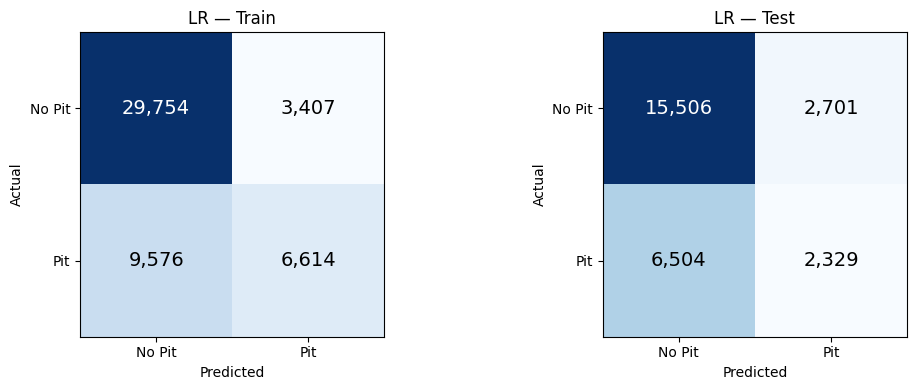

In [18]:
lr_proba_train = lr_model.predict_proba(X_train)
lr_proba_test  = lr_model.predict_proba(X_test)
lr_pred_train  = (lr_proba_train >= 0.5).astype(int)
lr_pred_test   = (lr_proba_test >= 0.5).astype(int)

print('--- Logistic Regression | Threshold = 0.5 ---\n')
lr_train_m = evaluate_model(y_train, lr_pred_train, lr_proba_train, 'LR (Train)')
print()
lr_test_m  = evaluate_model(y_test, lr_pred_test, lr_proba_test, 'LR (Test)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion_matrix(y_train, lr_pred_train, 'LR — Train', axes[0])
plot_confusion_matrix(y_test,  lr_pred_test,  'LR — Test',  axes[1])
plt.tight_layout(); plt.show()

---
## 6. Train & Evaluate ANN (1 Hidden Layer)

Architecture: **16 → 128 (ReLU) → 1 (Sigmoid)**

Hyperparameters:
- Learning rate: 0.01
- Epochs: 100
- Batch size: 256

In [19]:
ANN_EPOCHS = 100
ANN_LR = 0.01
ANN_BS = 256
INPUT_SIZE = X_train.shape[1]

np.random.seed(SEED)
ann = ANN(layer_sizes=[INPUT_SIZE, 128, 1], learning_rate=ANN_LR)
ann.train(X_train, y_train, epochs=ANN_EPOCHS, batch_size=ANN_BS,
          X_val=X_val_fold, y_val=y_val_fold, verbose=True)

print(f'\nFinal train loss: {ann.loss_history[-1]:.4f}')

Epoch  20/100 | Train Loss: 0.4919 | Val Loss: 0.4809
Epoch  40/100 | Train Loss: 0.4679 | Val Loss: 0.5332
Epoch  60/100 | Train Loss: 0.4578 | Val Loss: 0.4524
Epoch  80/100 | Train Loss: 0.4530 | Val Loss: 0.4378
Epoch 100/100 | Train Loss: 0.4468 | Val Loss: 0.4653

Final train loss: 0.4468


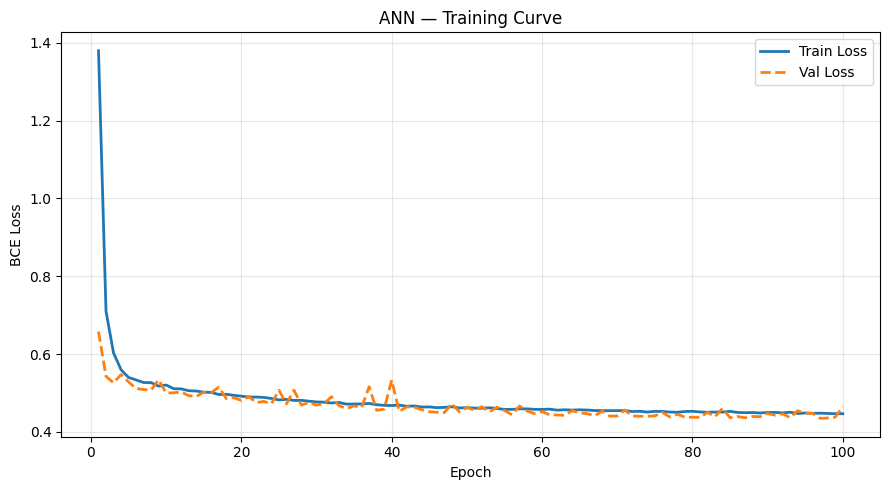

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(ann.loss_history)+1), ann.loss_history, label='Train Loss', lw=2)
ax.plot(range(1, len(ann.val_loss_history)+1), ann.val_loss_history,
        label='Val Loss', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('ANN — Training Curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

--- ANN 1-Layer | Threshold = 0.5 ---

=== ANN (Train) ===
  Accuracy:  0.7695
  Precision: 0.6207
  Recall:    0.7645
  F1 Score:  0.6852  <- primary
  ROC-AUC:   0.8477

=== ANN (Test) ===
  Accuracy:  0.7441
  Precision: 0.6032
  Recall:    0.6334
  F1 Score:  0.6179  <- primary
  ROC-AUC:   0.7943


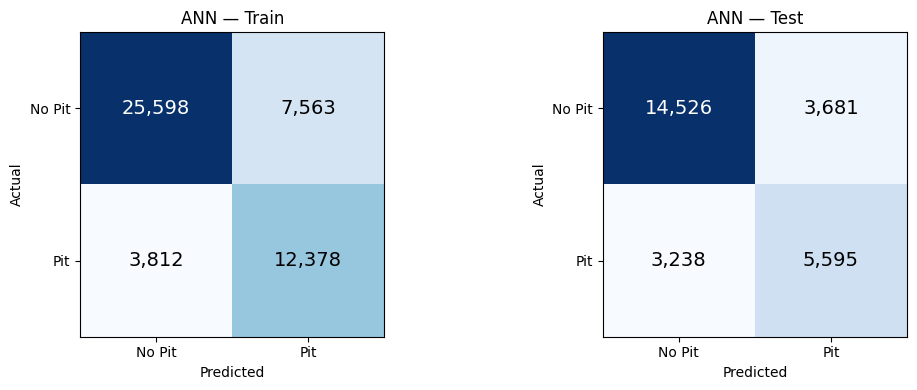

In [21]:
ann_proba_train = ann.predict_proba(X_train)
ann_proba_test  = ann.predict_proba(X_test)
ann_pred_train  = (ann_proba_train >= 0.5).astype(int)
ann_pred_test   = (ann_proba_test >= 0.5).astype(int)

print('--- ANN 1-Layer | Threshold = 0.5 ---\n')
ann_train_m = evaluate_model(y_train, ann_pred_train, ann_proba_train, 'ANN (Train)')
print()
ann_test_m  = evaluate_model(y_test, ann_pred_test, ann_proba_test, 'ANN (Test)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion_matrix(y_train, ann_pred_train, 'ANN — Train', axes[0])
plot_confusion_matrix(y_test,  ann_pred_test,  'ANN — Test',  axes[1])
plt.tight_layout(); plt.show()

---
## 7. Threshold Tuning Experiment

**Protocol (avoids data leakage):**
1. Train each model on **2022 only**
2. Find optimal threshold on **2024 (validation set)** via Precision-Recall curve
3. Apply that threshold to the **full models** (trained on 2022+2024)
4. Evaluate on **2025 (test set)**

**Comparison:** Default (t=0.5) vs Tuned threshold, with absolute Delta for each metric.

In [22]:
print('Training fold models (2022 only) for threshold tuning...\n')

np.random.seed(SEED)
lr_fold = LogisticRegression(input_size=INPUT_SIZE, learning_rate=LR_LR)
lr_fold.train(X_train_fold, y_train_fold, epochs=LR_EPOCHS, batch_size=LR_BS, verbose=False)

np.random.seed(SEED)
ann_fold = ANN(layer_sizes=[INPUT_SIZE, 128, 1], learning_rate=ANN_LR)
ann_fold.train(X_train_fold, y_train_fold, epochs=ANN_EPOCHS, batch_size=ANN_BS, verbose=False)

lr_val_proba  = lr_fold.predict_proba(X_val_fold)
ann_val_proba = ann_fold.predict_proba(X_val_fold)

lr_opt_t,  lr_opt_f1  = find_optimal_threshold(y_val_fold, lr_val_proba)
ann_opt_t, ann_opt_f1 = find_optimal_threshold(y_val_fold, ann_val_proba)

print(f'LR  — Optimal t: {lr_opt_t:.4f}  (Val F1: {lr_opt_f1:.4f})')
print(f'ANN — Optimal t: {ann_opt_t:.4f}  (Val F1: {ann_opt_f1:.4f})')

Training fold models (2022 only) for threshold tuning...

LR  — Optimal t: 0.2424  (Val F1: 0.6170)
ANN — Optimal t: 0.2418  (Val F1: 0.6653)


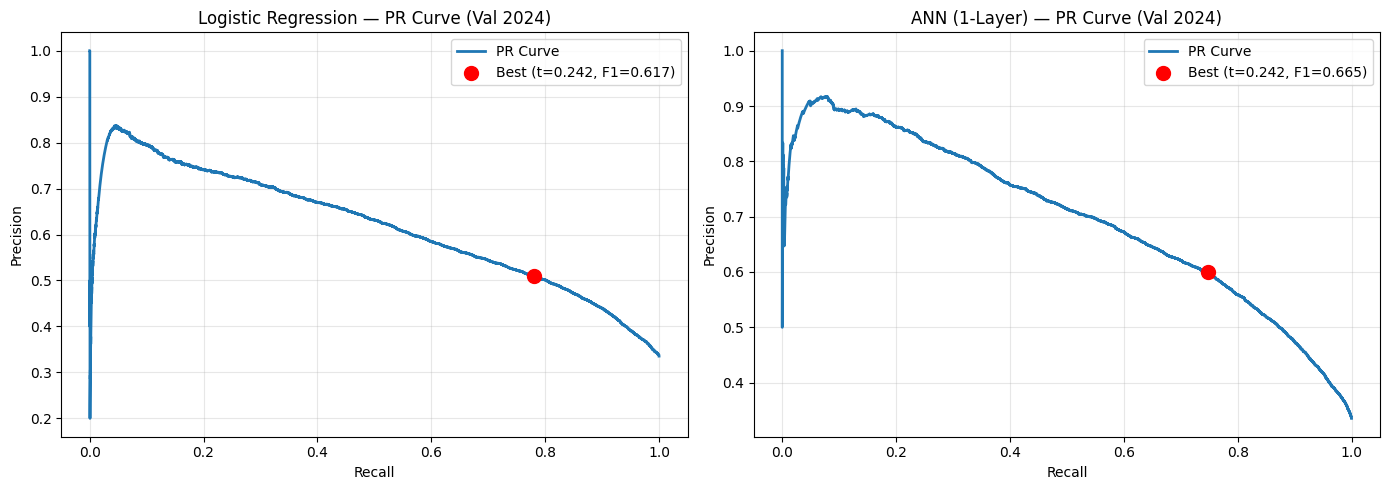

In [23]:
# PR curves on validation set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, name, opt_t in [
    (axes[0], lr_val_proba,  'Logistic Regression', lr_opt_t),
    (axes[1], ann_val_proba, 'ANN (1-Layer)',       ann_opt_t),
]:
    precs, recs, threshs = precision_recall_curve_manual(y_val_fold, proba)
    f1s = 2 * precs * recs / (precs + recs + 1e-8)
    best_idx = np.argmax(f1s)
    ax.plot(recs, precs, lw=2, label='PR Curve')
    ax.scatter(recs[best_idx], precs[best_idx], color='red', s=100, zorder=5,
               label=f'Best (t={opt_t:.3f}, F1={f1s[best_idx]:.3f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{name} — PR Curve (Val 2024)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

=== Threshold Tuning Results (Test Set 2025) ===

=== LR (t=0.242) ===
  Accuracy:  0.5966
  Precision: 0.4301
  Recall:    0.7218
  F1 Score:  0.5390  <- primary
  ROC-AUC:   0.6663

=== ANN (t=0.242) ===
  Accuracy:  0.6559
  Precision: 0.4853
  Recall:    0.8825
  F1 Score:  0.6263  <- primary
  ROC-AUC:   0.7943


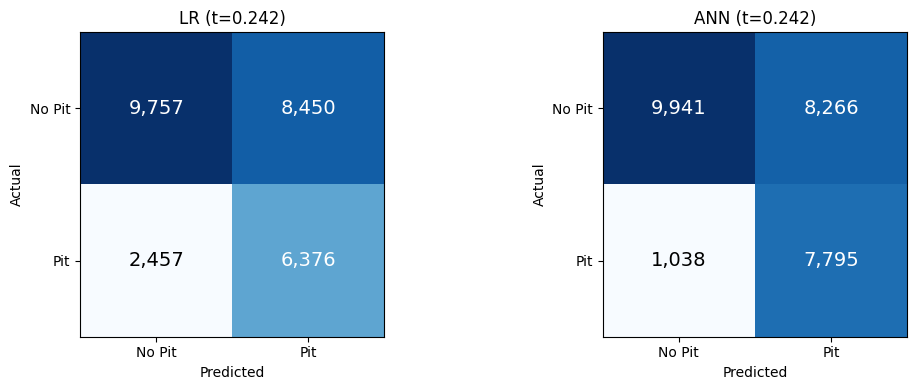

In [24]:
print('=== Threshold Tuning Results (Test Set 2025) ===\n')

lr_pred_test_opt = (lr_proba_test >= lr_opt_t).astype(int)
lr_test_opt_m = evaluate_model(y_test, lr_pred_test_opt, lr_proba_test,
                                f'LR (t={lr_opt_t:.3f})')
print()

ann_pred_test_opt = (ann_proba_test >= ann_opt_t).astype(int)
ann_test_opt_m = evaluate_model(y_test, ann_pred_test_opt, ann_proba_test,
                                 f'ANN (t={ann_opt_t:.3f})')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_confusion_matrix(y_test, lr_pred_test_opt,  f'LR (t={lr_opt_t:.3f})',  axes[0])
plot_confusion_matrix(y_test, ann_pred_test_opt, f'ANN (t={ann_opt_t:.3f})', axes[1])
plt.tight_layout(); plt.show()

---
## 8. Threshold Experiment — Structured Comparison

Side-by-side: Default (t=0.5) vs Tuned threshold, with absolute Delta.

In [25]:
print('=== Threshold Experiment — Structured Comparison (Test Set) ===\n')

for default_m, tuned_m, opt_t, name in [
    (lr_test_m,  lr_test_opt_m,  lr_opt_t,  'Logistic Regression'),
    (ann_test_m, ann_test_opt_m, ann_opt_t, 'ANN (1-Layer)'),
]:
    rows = []
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        d = default_m[metric]; t = tuned_m[metric]
        label = 'F1 *' if metric == 'f1' else metric.upper()
        rows.append({
            'Metric': label,
            'Default (t=0.5)': f'{d:.4f}',
            f'Tuned (t={opt_t:.3f})': f'{t:.4f}',
            'Delta': f'{t - d:+.4f}'
        })
    sub_df = pd.DataFrame(rows)
    print(f'--- {name} ---')
    print(sub_df.to_string(index=False))
    print()

=== Threshold Experiment — Structured Comparison (Test Set) ===

--- Logistic Regression ---
   Metric Default (t=0.5) Tuned (t=0.242)   Delta
 ACCURACY          0.6596          0.5966 -0.0629
PRECISION          0.4630          0.4301 -0.0330
   RECALL          0.2637          0.7218 +0.4582
     F1 *          0.3360          0.5390 +0.2030
      AUC          0.6663          0.6663 +0.0000

--- ANN (1-Layer) ---
   Metric Default (t=0.5) Tuned (t=0.242)   Delta
 ACCURACY          0.7441          0.6559 -0.0882
PRECISION          0.6032          0.4853 -0.1178
   RECALL          0.6334          0.8825 +0.2491
     F1 *          0.6179          0.6263 +0.0083
      AUC          0.7943          0.7943 +0.0000



## 9. ROC Curves

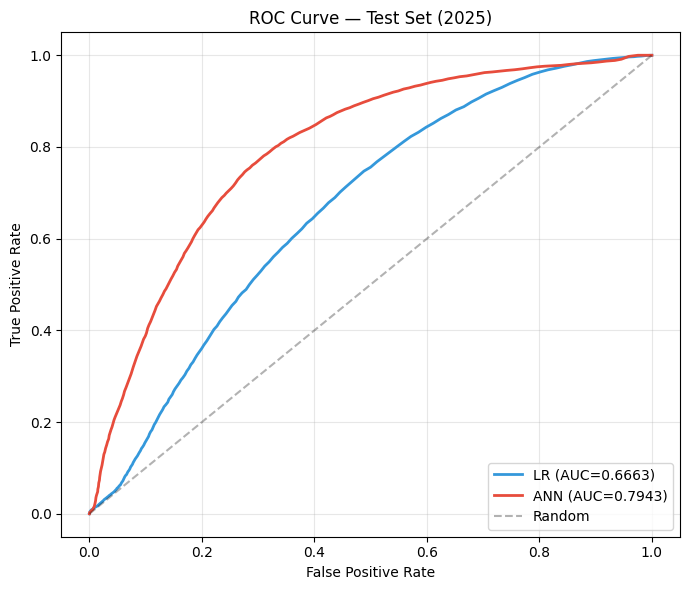

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))

for proba, name, color in [
    (lr_proba_test,  'LR',  '#3498db'),
    (ann_proba_test, 'ANN', '#e74c3c'),
]:
    fpr, tpr = roc_curve_manual(y_test, proba)
    auc_val = compute_auc(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set (2025)')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10. Model Comparison & Ablation Summary

=== Full Model Comparison (Test Set 2025) ===
               accuracy  precision  recall      f1     auc
model                                                     
LR (Test)        0.6596     0.4630  0.2637  0.3360  0.6663
ANN (Test)       0.7441     0.6032  0.6334  0.6179  0.7943
LR (t=0.242)     0.5966     0.4301  0.7218  0.5390  0.6663
ANN (t=0.242)    0.6559     0.4853  0.8825  0.6263  0.7943

* F1 is primary metric

>>> Best model by F1: ANN (t=0.242) (F1 = 0.6263)


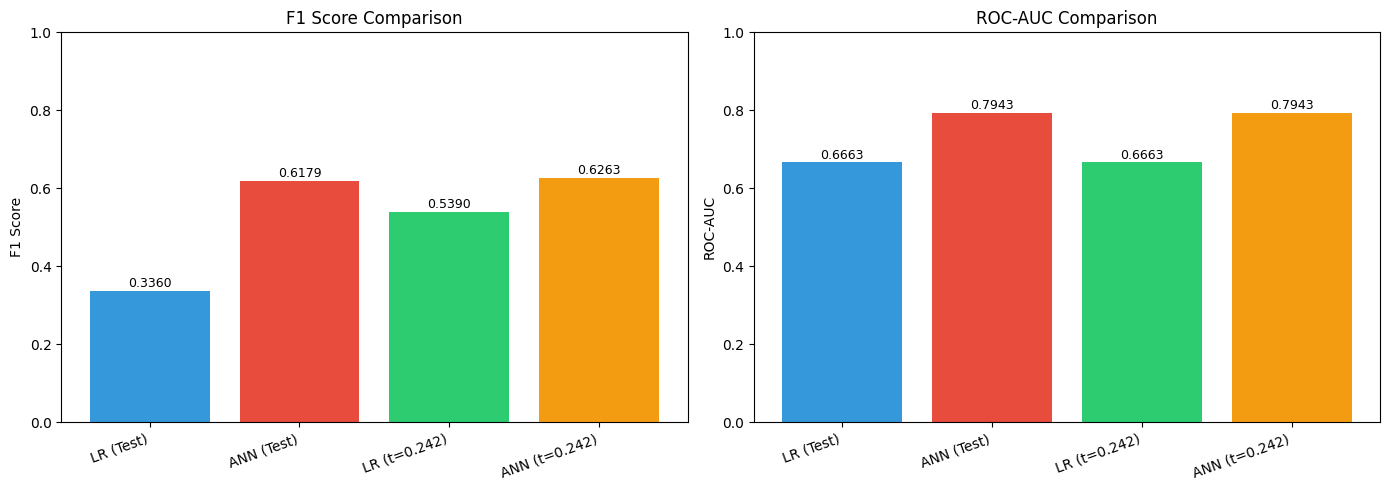

In [27]:
all_results = [
    lr_test_m, ann_test_m,          # default threshold
    lr_test_opt_m, ann_test_opt_m,  # tuned threshold
]

full_df = pd.DataFrame(all_results).set_index('model').round(4)
print('=== Full Model Comparison (Test Set 2025) ===')
print(full_df.to_string())
print(f'\n* F1 is primary metric')

best_row = full_df['f1'].idxmax()
print(f'\n>>> Best model by F1: {best_row} (F1 = {full_df.loc[best_row, "f1"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
bars = axes[0].bar(full_df.index, full_df['f1'], color=colors)
axes[0].set_ylabel('F1 Score'); axes[0].set_title('F1 Score Comparison')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars, full_df['f1']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

bars2 = axes[1].bar(full_df.index, full_df['auc'], color=colors)
axes[1].set_ylabel('ROC-AUC'); axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, full_df['auc']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=9)
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')
plt.tight_layout(); plt.show()

## 11. Feature Importance (LR Coefficients)

Top features by |coefficient|:
               feature  coefficient  abs_coef
              TyreLife     1.300184  1.300184
                 Stint     1.032432  1.032432
 Compound_INTERMEDIATE    -0.626869  0.626869
             LapNumber    -0.531304  0.531304
          RaceProgress    -0.516651  0.516651
          Compound_WET    -0.484018  0.484018
       Compound_MEDIUM    -0.430649  0.430649
         Compound_HARD     0.349379  0.349379
         Compound_SOFT     0.256186  0.256186
Cumulative_Degradation     0.184561  0.184561
              Position    -0.134361  0.134361
      Degradation_Rate    -0.124562  0.124562
           LapTime (s)    -0.067994  0.067994
         LapTime_Delta     0.060784  0.060784
       Position_Change     0.059122  0.059122
        Driver_encoded     0.004703  0.004703


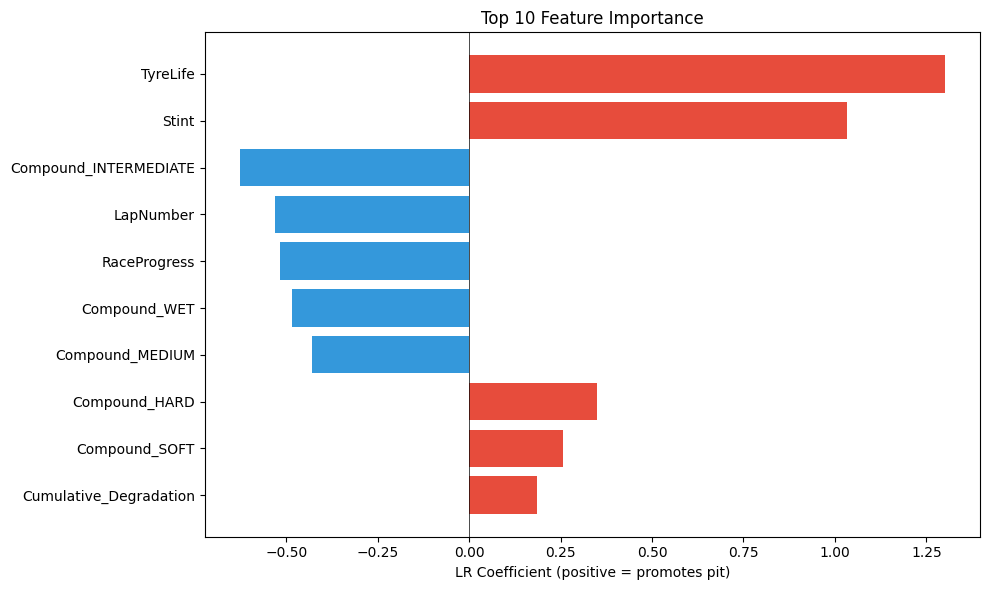

In [28]:
coef = lr_model.W
importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': coef,
    'abs_coef': np.abs(coef)
}).sort_values('abs_coef', ascending=False)

print('Top features by |coefficient|:')
print(importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
imp = importance.head(10)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in imp['coefficient']]
ax.barh(range(len(imp)), imp['coefficient'], color=colors)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp['feature'])
ax.set_xlabel('LR Coefficient (positive = promotes pit)')
ax.set_title('Top 10 Feature Importance')
ax.invert_yaxis(); ax.axvline(x=0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

---
## 12. Save Artifacts

All deployment-critical outputs saved as explicit files.  
`inference.py` reads these — no dependency on notebooks at runtime.

In [29]:
artifact_dir = 'Dataset'

# 1. Feature order (locked)
feature_order_path = os.path.join(artifact_dir, 'feature_order.json')
with open(feature_order_path, 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f'Saved: {feature_order_path}')

# 2. Model weights (LR + ANN only)
weights_path = os.path.join(artifact_dir, 'model_weights.npz')
weight_dict = {
    'lr_W': lr_model.W, 'lr_b': np.array([lr_model.b]),
}
for i, (w, b) in enumerate(zip(ann.weights, ann.biases)):
    weight_dict[f'ann1_W{i}'] = w
    weight_dict[f'ann1_b{i}'] = b
np.savez(weights_path, **weight_dict)
print(f'Saved: {weights_path}')

# 3. Model config
candidates = {
    'lr':         {'f1': lr_test_opt_m['f1'],  'threshold': float(lr_opt_t),
                   'layer_sizes': [INPUT_SIZE, 1]},
    'ann_1layer': {'f1': ann_test_opt_m['f1'], 'threshold': float(ann_opt_t),
                   'layer_sizes': [INPUT_SIZE, 128, 1]},
}
best_name = max(candidates, key=lambda k: candidates[k]['f1'])
config = {
    'selected_model': best_name,
    'threshold': candidates[best_name]['threshold'],
    'layer_sizes': candidates[best_name]['layer_sizes'],
    'test_f1': candidates[best_name]['f1'],
    'all_thresholds': {
        'lr': float(lr_opt_t),
        'ann_1layer': float(ann_opt_t),
    },
    'seed': SEED
}
config_path = os.path.join(artifact_dir, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved: {config_path}')
print(f'\n>>> Selected model: {best_name} (F1={candidates[best_name]["f1"]:.4f}, t={candidates[best_name]["threshold"]:.4f})')

assert os.path.exists(os.path.join(artifact_dir, 'scaler_params.csv')), 'scaler_params.csv missing!'
assert os.path.exists(os.path.join(artifact_dir, 'driver_mapping.csv')), 'driver_mapping.csv missing!'
print(f'\nVerified: scaler_params.csv exists')
print(f'Verified: driver_mapping.csv exists')
print(f'\n=== All artifacts saved to {artifact_dir}/ ===')

Saved: Dataset/feature_order.json
Saved: Dataset/model_weights.npz
Saved: Dataset/model_config.json

>>> Selected model: ann_1layer (F1=0.6263, t=0.2418)

Verified: scaler_params.csv exists
Verified: driver_mapping.csv exists

=== All artifacts saved to Dataset/ ===


---
## 13. Grid Search Framework

Skeleton for hyperparameter tuning via time-series CV. Uncomment when ready.

In [19]:
# === GRID SEARCH FRAMEWORK (uncomment when ready) ===

# from itertools import product
# 
# ann_param_grid = {
#     'hidden_sizes': [[64, 1], [128, 1], [256, 1]],
#     'learning_rate': [0.001, 0.01, 0.05],
#     'epochs': [50, 100, 200],
#     'batch_size': [128, 256, 512]
# }
# 
# best_f1 = 0; best_params = None
# for hs, lr_val, ep, bs in product(
#     ann_param_grid['hidden_sizes'],
#     ann_param_grid['learning_rate'],
#     ann_param_grid['epochs'],
#     ann_param_grid['batch_size']
# ):
#     np.random.seed(SEED)
#     sizes = [INPUT_SIZE] + hs
#     model = ANN(layer_sizes=sizes, learning_rate=lr_val)
#     model.train(X_train_fold, y_train_fold, epochs=ep, batch_size=bs, verbose=False)
#     pred = model.predict(X_val_fold)
#     m = compute_metrics(y_val_fold, pred, model.predict_proba(X_val_fold))
#     if m['f1'] > best_f1:
#         best_f1 = m['f1']
#         best_params = {'hidden_sizes': hs, 'lr': lr_val, 'epochs': ep, 'bs': bs}
#         print(f'New best F1={m["f1"]:.4f} | {best_params}')
# print(f'Best: {best_params}, F1={best_f1:.4f}')

print('[Grid Search] — Skeleton ready. Uncomment to run.')

[Grid Search] — Skeleton ready. Uncomment to run.


## 14. Class Weight Experiment (Ablation)

Compare baseline (no weighting) vs weighted BCE loss. Uncomment when ready.

In [30]:
# pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# print(f'pos_weight = {pos_weight:.2f}')
# Modify ANN.compute_loss for weighted BCE:
# weighted_loss = -mean( pos_weight * y * log(A) + (1-y) * log(1-A) )

print('[Class Weight Experiment] — Skeleton ready. Uncomment to run.')

[Class Weight Experiment] — Skeleton ready. Uncomment to run.


---
## Summary

| Item | Detail |
|------|--------|
| **Model 1** | Logistic Regression (NumPy from scratch) |
| **Model 2** | ANN: 16 → 128 (ReLU) → 1 (Sigmoid), NumPy from scratch |
| **Loss** | Binary Cross-Entropy |
| **Optimizer** | Mini-batch SGD |
| **Primary Metric** | F1 Score |
| **All Metrics** | Accuracy, Precision, Recall, F1, ROC-AUC |
| **Threshold** | Optimized via PR curve on Val set (2024) |
| **Train** | 2022 + 2024 (49,351 rows) |
| **Test** | 2025 (27,040 rows) |
| **Seed** | 5368 (project-specific) |

**Artifacts saved to `Dataset/`:**
- `feature_order.json` — locked feature column order
- `scaler_params.csv` — standardization mean/std
- `driver_mapping.csv` — Driver → integer encoding
- `model_weights.npz` — LR + ANN weights
- `model_config.json` — selected model, threshold, layer sizes

**Deployment:** `inference.py` reads these artifacts for Streamlit integration.

---
## 📊 Final Model Metrics Summary

All models evaluated on **Test Set (2025)**.

| Model | Threshold | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|-----------|----------|-----------|--------|----------|---------|
| **LR (Default)** | 0.5000 | 0.6596 | 0.4630 | 0.2637 | 0.3360 | 0.6663 |
| **LR (Tuned)** | 0.2424 | 0.5966 | 0.4301 | 0.7218 | **0.5390** | 0.6663 |
| **ANN (Default)** | 0.5000 | 0.7441 | 0.6032 | 0.6334 | 0.6179 | 0.7943 |
| **ANN (Tuned)** | 0.2418 | 0.6559 | 0.4853 | 0.8825 | **0.6263** ⭐ | 0.7943 |

**Observations:**
- **Best model (⭐):** ANN (1-Layer) with tuned threshold t=0.2418 → **F1 = 0.6263**
- **Threshold impact:** Tuning shifts focus from precision → recall, improving F1 significantly
- **LR improvement:** t=0.2424 gains +0.2030 F1 vs default (+0.4582 recall at cost of -0.0629 accuracy)
- **ANN improvement:** t=0.2418 gains +0.0083 F1 vs default (already strong at default; high recall at 0.8825)
- **AUC (ranking):** Both models unchanged at tuned threshold (AUC is threshold-agnostic). ANN > LR (0.7943 vs 0.6663)
